# **EDA & NLP Analysis — electricalworld.com | Electronics & Technology**

### **Libraries**

In [38]:
import re
import numpy as np
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler
from transformers import pipeline

from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import unicodedata
import logging
from typing import Optional

from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
from transformers import pipeline as hf_pipeline

# Own libraries
import sys
if '../src' not in sys.path:
    sys.path.append('../src')
import cleaning
import eda
import nlp

### **Sector & Company Configuration**

In [39]:
TARGET = "electricalworld.com"
CAT = "Electronics & Technology"

### **Data Load**

#### **Companies Dataset**
- This dataset is going to be loaded just to visualize which portion of the total each `category` represents.
- In this dataset all companies have the maximum of a **100** reviews.
- The values of the columns: `median_stars`, `media_stars`, `std_stars`, are the same for all countries, so no additional information is given.

In [40]:
company_category = pd.read_excel("../datasets/emp_100_reviews.xlsx")
company_category.head()

,category,company,n_reviews,median_stars,media_stars,std_stars
0,Animals & Pets,gardenbird.co.uk,100,3,3,1.421338
1,Restaurants & Bars,www.brewersfayre.co.uk,100,3,3,1.421338
2,Restaurants & Bars,mindfulchef.com,100,3,3,1.421338
3,Restaurants & Bars,nonnatonda.co.uk,100,3,3,1.421338
4,Restaurants & Bars,planthood.co.uk,100,3,3,1.421338


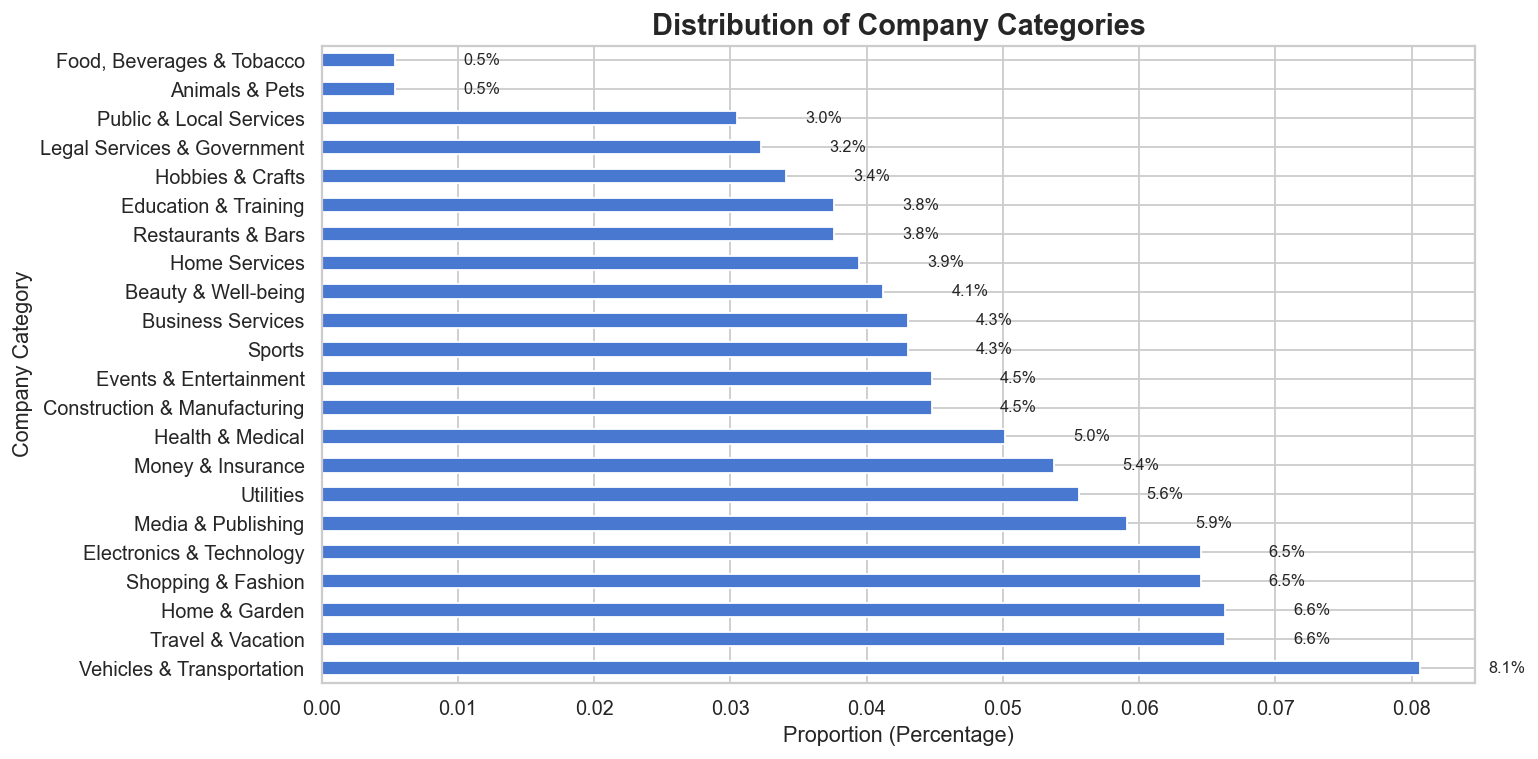

In [41]:
# Get the normalized value counts
category_props = company_category['category'].value_counts(normalize=True)

# Create horizontal barplot
plt.figure(figsize=(12, 6))

# Create horizontal bars
category_props.plot(kind='barh')

# Add titles and labels
plt.title('Distribution of Company Categories', fontsize=16, fontweight='bold')
plt.xlabel('Proportion (Percentage)', fontsize=12)
plt.ylabel('Company Category', fontsize=12)

# Add percentage labels on bars
for i, (category, value) in enumerate(category_props.items()):
    plt.text(value + 0.005, i, f'{value:.1%}', 
             va='center', fontsize=9)

plt.tight_layout()
plt.show()

For this project we are going to work with a company of the `Electronics & Technology` category. However the procedure followed is going to be exactly the same for all categories.

Now let's see the companies of this category that have a **100 reviews** 

In [42]:
company_category.loc[company_category['category']==CAT, 'company'].unique()

<ArrowStringArray>
[                 'backmarket.co.uk',             'hotpointservice.co.uk',
                     'belling.co.uk',                         'bopdj.com',
               'directvacuums.co.uk',               'electricalworld.com',
                      'giffgaff.com',                   'go-assist.co.uk',
                       'gtech.co.uk',                      'hughes.co.uk',
                   'www.tayna.co.uk',                'www.mrmemory.co.uk',
              'www.partmaster.co.uk',              'www.petertyson.co.uk',
              'www.richersounds.com', 'www.sevenoakssoundandvision.co.uk',
             'www.sonicdirect.co.uk',                     'www.vax.co.uk',
                 'mobiletopup.co.uk',         'www.markselectrical.co.uk',
                'www.lcegroup.co.uk',                   'www.jessops.com',
                'www.idmobile.co.uk',                  'www.hivehome.com',
                   'www.ghdhair.com',                 'www.espares.co.uk',
      

#### **Reviews Dataset**

In [43]:
df = pd.read_csv("../datasets/trustpilot-reviews-123k.csv")
df[df['category']==CAT].head()

,category,company,description,title,review,stars
29662,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Dave 55,Excellent service as always shout out to Jerom...,5
29663,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Great service from Richer Sounds…,Great service from the Richer Sounds team at S...,5
29664,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Wanted a TV for an 84 year old relative…,Wanted a TV for an 84 year old relative who’s ...,5
29665,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,IMFORMED FRIENDLY HELP FROM RICHER SOUNDS,Excellent rapport and helpfulness with your So...,5
29666,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Purchase of Hi-Fi Equipment From Richer Sounds,"The Sales Assistant, Richard, was very helpful...",5


In [44]:
df_clean = cleaning.clean_reviews_by_category(df, CAT)
df_clean.head()

2026-04-16 11:01:20,613 [INFO] Filtering to category: 'Electronics & Technology' ...
2026-04-16 11:01:20,622 [INFO]   → 5,596 rows found across 69 companies.
2026-04-16 11:01:20,623 [INFO] Cleaning text columns: ['title', 'review', 'description'] ...
2026-04-16 11:01:20,709 [INFO]  ✓ 'title'
2026-04-16 11:01:20,993 [INFO]  ✓ 'review'
2026-04-16 11:01:21,515 [INFO]  ✓ 'description'
2026-04-16 11:01:21,518 [INFO] Cleaning complete.


,category,company,description,title,review,stars
0,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Dave 55,Excellent service as always shout out to Jerom...,5
1,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Great service from Richer Sounds...,Great service from the Richer Sounds team at S...,5
2,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Wanted a TV for an 84 year old relative...,Wanted a TV for an 84 year old relative whos s...,5
3,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,IMFORMED FRIENDLY HELP FROM RICHER SOUNDS,Excellent rapport and helpfulness with your So...,5
4,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Purchase of Hi-Fi Equipment From Richer Sounds,"The Sales Assistant, Richard, was very helpful...",5


In [45]:
df['stars'].describe()

count    123181.000000
mean          3.182658
std           1.470769
min           1.000000
25%           2.000000
50%           3.000000
75%           5.000000
max           5.000000
Name: stars, dtype: float64

## **1. EDA — Sector Overview**

In [46]:
eda.dataset_overview(df_clean)

print("\nComputing company stats ...")
df_feat = eda.add_length_features(df_clean)
display(df_feat)
stats = eda.company_stats(df_feat)
display(stats)

print(f"\n  {len(stats)} companies found. Stats summary:")
print(stats.describe().round(2).to_string())


  DATASET OVERVIEW
  Total reviews      : 5,596
  Unique companies   : 69
  Star range         : 1 – 5
  Avg stars (global) : 3.17

        nulls  empty_strings
column                      
title       0              0
review      0              0
stars       0              0

Computing company stats ...


,category,company,description,title,review,stars,title_char_len,title_word_count,review_char_len,review_word_count
0,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Dave 55,Excellent service as always shout out to Jerom...,5,7,2,407,69
1,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Great service from Richer Sounds...,Great service from the Richer Sounds team at S...,5,35,5,343,63
2,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Wanted a TV for an 84 year old relative...,Wanted a TV for an 84 year old relative whos s...,5,42,9,282,54
3,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,IMFORMED FRIENDLY HELP FROM RICHER SOUNDS,Excellent rapport and helpfulness with your So...,5,41,6,308,52
4,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Purchase of Hi-Fi Equipment From Richer Sounds,"The Sales Assistant, Richard, was very helpful...",5,46,7,361,65
...,...,...,...,...,...,...,...,...,...,...
5591,Electronics & Technology,synthesia.io,Synthesia is the world's 1 AI video communicat...,Synthesia braucht Stunden um ein einfaches 1 m...,"Du erstellst ein Video auf synthesia.io1,03 mi...",1,67,10,3561,580
5592,Electronics & Technology,synthesia.io,Synthesia is the world's 1 AI video communicat...,False advertising and poor client experience,The videos are good but the client experience ...,1,44,6,351,56
5593,Electronics & Technology,synthesia.io,Synthesia is the world's 1 AI video communicat...,Unusable Service and a Refund Policy Thats a R...,My experience with Synthesia has been nothing ...,1,92,14,775,123
5594,Electronics & Technology,synthesia.io,Synthesia is the world's 1 AI video communicat...,Beware No-Refund Policy and Unusable App Features,Ive had a frustrating experience with Synthesi...,1,49,7,838,131


,review_count,avg_stars,pct_positive,pct_negative,avg_review_words,avg_title_words
company,,,,,,
brokenfones.com,20,5.00,100.00,0.00,33.40,5.00
licensel.com,22,4.86,100.00,0.00,14.64,3.55
pcrepairscheshire.co.uk,24,4.83,100.00,0.00,40.04,3.92
wildviewcameras.co.uk,26,4.77,100.00,0.00,39.88,3.92
techformusic.co.uk,30,4.67,100.00,0.00,41.60,4.20
...,...,...,...,...,...,...
www.richersounds.com,100,3.00,40.00,40.00,78.02,6.08
www.yourspares.co.uk,99,3.00,40.40,40.40,47.59,5.20
juicebitz.co.uk,99,2.99,39.39,40.40,66.17,5.67



  69 companies found. Stats summary:
       review_count  avg_stars  pct_positive  pct_negative  avg_review_words  avg_title_words
count         69.00      69.00         69.00         69.00             69.00            69.00
mean          81.10       3.38         53.65         30.23             58.74             5.17
std           28.28       0.62         21.63         14.85             15.94             0.51
min           20.00       2.99         39.39          0.00             14.64             3.55
25%           59.00       3.00         40.00         19.44             47.59             5.00
50%          100.00       3.00         40.00         40.00             60.83             5.22
75%          100.00       3.60         65.00         40.00             66.95             5.43
max          100.00       5.00        100.00         40.82            104.74             6.27


### **1.1 Star Rating Distribution (sector-wide)**

2026-04-16 11:01:21,660 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-16 11:01:21,662 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


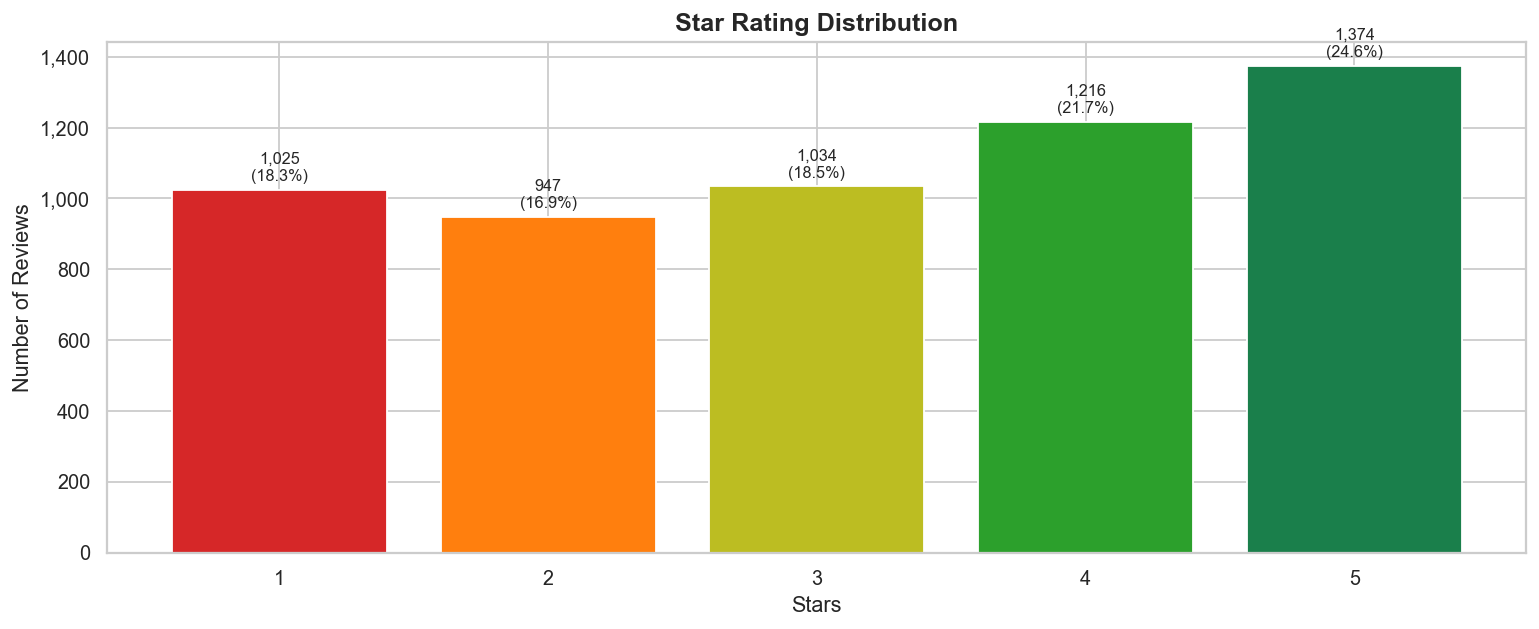

In [47]:
eda.plot_star_distribution(df_feat)

The rating distribution across the Electronics & Technology sector is
remarkably **flat and polarised**. No single star rating dominates:
- 5-star reviews lead slightly at 24.6% (1,374), but 1-star reviews are
the second most common at 18.3% (1,025), closely followed by 3-star
(18.5%) and 2-star (16.9%). 

This bimodal pattern — many very happy and
many very unhappy customers — is characteristic of electronics retail,
where post-purchase issues (faulty products, delivery failures) generate
strong negative reactions while smooth transactions generate strong
praise. The near-equal split means **sentiment is genuinely contested**
in this sector, unlike categories where 5-star reviews dominate.

### **1.2 Top & Bottom 10 Companies by Avg Stars**

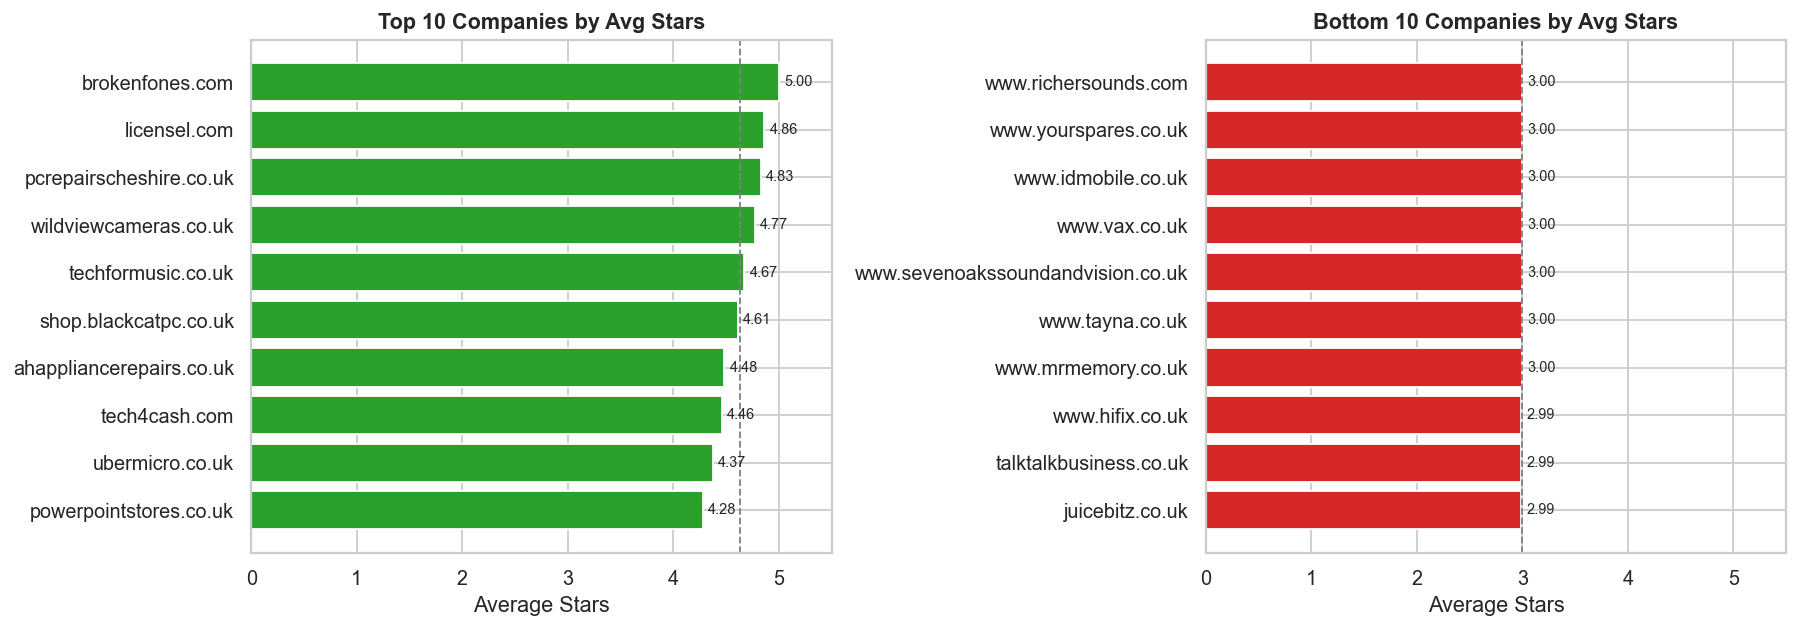

In [48]:
eda.plot_avg_stars_per_company(stats)

The top performers are dominated by **small specialist retailers**
(brokenfones.com at 5.00, licensel.com at 4.86, pcrepairscheshire.co.uk
at 4.83), all of which likely benefit from a niche focus and personalised
service. 

The bottom 10 cluster tightly around **3.00 stars**, suggesting
a floor effect — these companies are not catastrophically bad but are
consistently mediocre, unable to differentiate themselves positively.


Notably, the gap between the best (5.00) and worst (2.99) companies is
almost 2 full stars, indicating **high performance dispersion** within
the sector. This is an opportunity: the bar for standing out is high,
but the gap from mediocre to excellent is achievable.

### **1.3 Review Word Count Distribution by Sentiment**

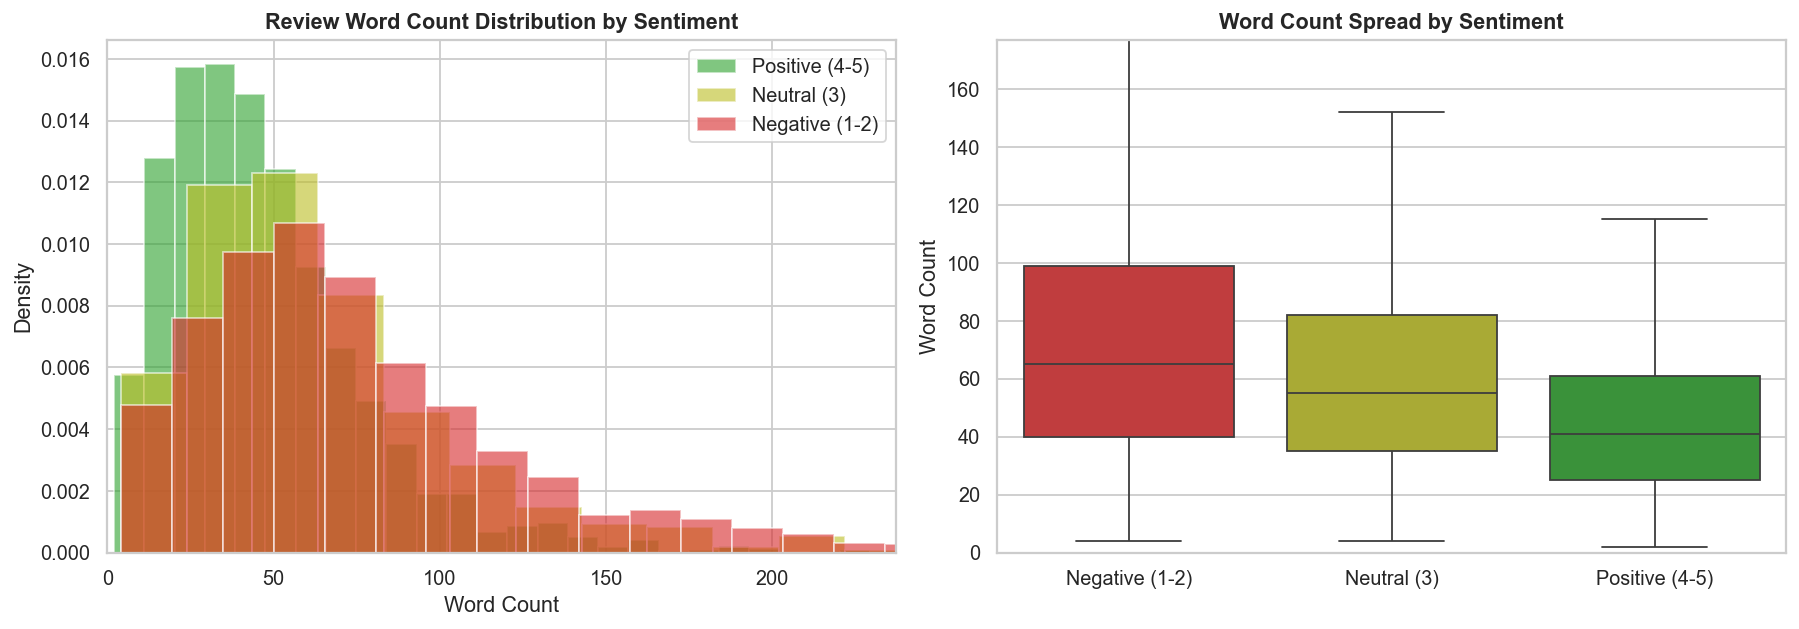

In [49]:
eda.plot_review_length_distribution(df_feat)

Negative reviewers write significantly **longer reviews** than positive
ones. The box plot makes this stark: negative reviews (1–2★) have a
median around 65 words and a wide IQR extending to ~100 words, while
positive reviews (4–5★) cluster below 60 words with a much tighter
spread. This is a well-known behavioural pattern — dissatisfied
customers feel compelled to explain and justify their complaint in
detail, while happy customers often leave short confirmatory reviews
("great service, fast delivery"). For NLP purposes, this means
**negative reviews carry richer topic signal** and are worth analysing
in more depth.

### **1.4 Top 15 Companies by Avg Review Word Count**

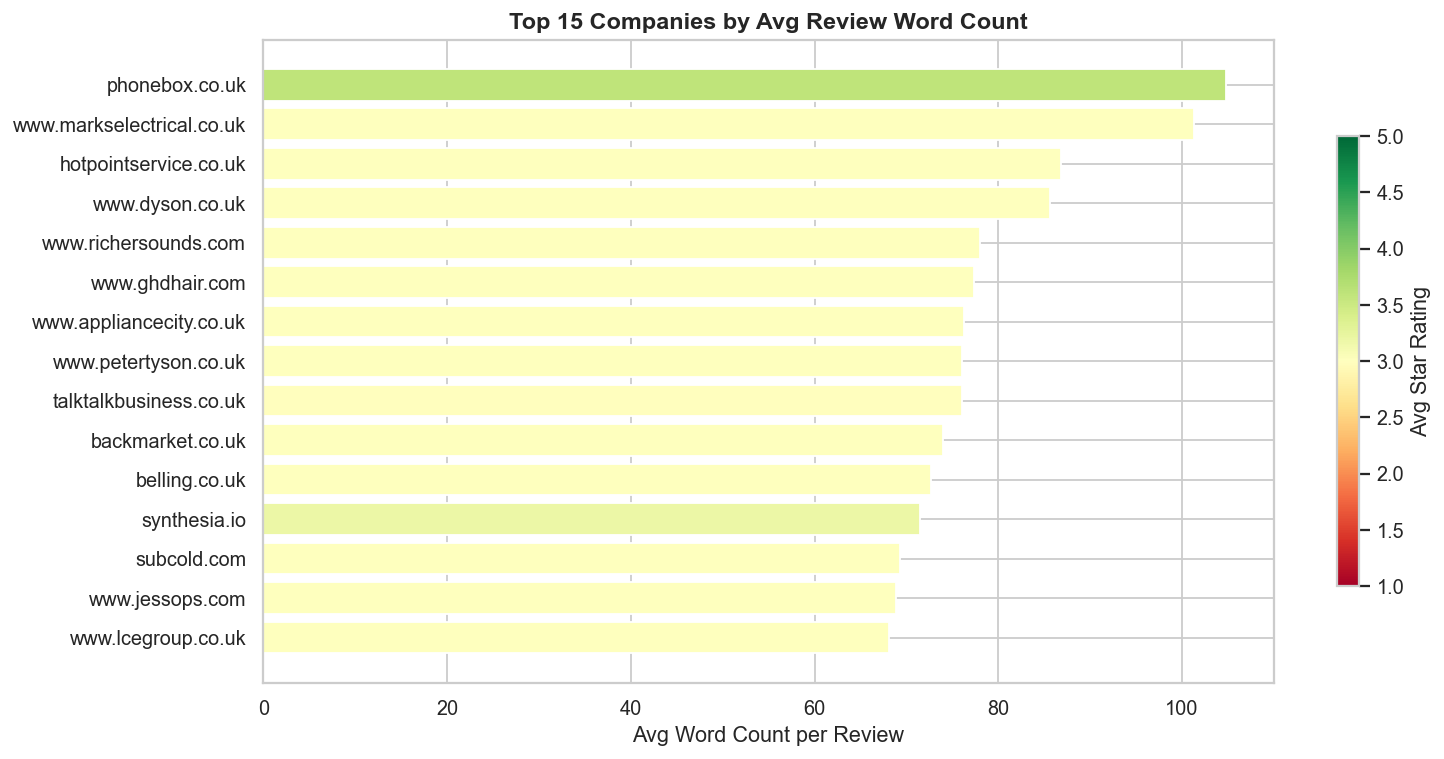

In [50]:
eda.plot_avg_review_length_per_company(stats)

Companies with the longest reviews tend to cluster around **3.0–3.5
average stars** (yellow-green on the colour scale), confirming the
sentiment–length relationship at company level. phonebox.co.uk leads
at ~105 words per review and sits in the 3.0–3.5 star range, suggesting
its customers are engaged but divided. The two clear green outliers —
synthesia.io and backmarket.co.uk — combine high word counts with
higher ratings, indicating customers who are genuinely enthusiastic
and detailed in their praise. electricalworld.com does not appear in
this top 15, suggesting its reviews are **shorter than sector average**,
which will be confirmed in the positioning analysis.

### **1.5 Company Summary Table (heatmap)**

In [51]:
display(eda.display_company_summary(stats))

,review_count,avg_stars,pct_positive,pct_negative,avg_review_words,avg_title_words
company,,,,,,
brokenfones.com,20,5.00,100.0%,0.0%,33,5
licensel.com,22,4.86,100.0%,0.0%,15,4
pcrepairscheshire.co.uk,24,4.83,100.0%,0.0%,40,4
wildviewcameras.co.uk,26,4.77,100.0%,0.0%,40,4
techformusic.co.uk,30,4.67,100.0%,0.0%,42,4
shop.blackcatpc.co.uk,28,4.61,92.9%,3.6%,45,5
ahappliancerepairs.co.uk,29,4.48,89.7%,6.9%,34,4
tech4cash.com,28,4.46,89.3%,7.1%,48,6
ubermicro.co.uk,30,4.37,90.0%,10.0%,39,4


The heatmap reveals a clean **bifurcation** in the sector: companies
in the top half (brokenfones, licensel, pcrepairscheshire) achieve
near-100% positive rates with 0% negative, while the bottom half
(phonebox, computerangels, scgconnected) see positive rates drop to
55–65% with negative rates climbing to 19–26%. The avg_review_words
column reinforces the earlier finding: phonebox.co.uk's 105-word
average is the highest in the table and coincides with its 26% negative
rate — its customers have a lot to complain about. electricalworld.com
is not visible in this top-20 slice, which foreshadows its low
percentile positioning.

## **2. Competitive Positioning — electricalworld.com**

In [52]:
target_stats = eda.build_stats(df_clean)

print(f"\n{'='*55}")
print(f"  COMPETITIVE POSITIONING — {TARGET}")
print(f"  Category : {CAT}")
print(f"  Companies: {target_stats['company'].nunique()}")
print(f"{'='*55}\n")

df_clean.loc[df_clean['company']==TARGET, 'description']


  COMPETITIVE POSITIONING — electricalworld.com
  Category : Electronics & Technology
  Companies: 69



4613    Now with over 16,000 Reviews on Reviews.io, El...
4614    Now with over 16,000 Reviews on Reviews.io, El...
4615    Now with over 16,000 Reviews on Reviews.io, El...
4616    Now with over 16,000 Reviews on Reviews.io, El...
4617    Now with over 16,000 Reviews on Reviews.io, El...
                              ...                        
4708    Now with over 16,000 Reviews on Reviews.io, El...
4709    Now with over 16,000 Reviews on Reviews.io, El...
4710    Now with over 16,000 Reviews on Reviews.io, El...
4711    Now with over 16,000 Reviews on Reviews.io, El...
4712    Now with over 16,000 Reviews on Reviews.io, El...
Name: description, Length: 100, dtype: str

### **2.1 Avg Star Rating Distribution (KDE)**

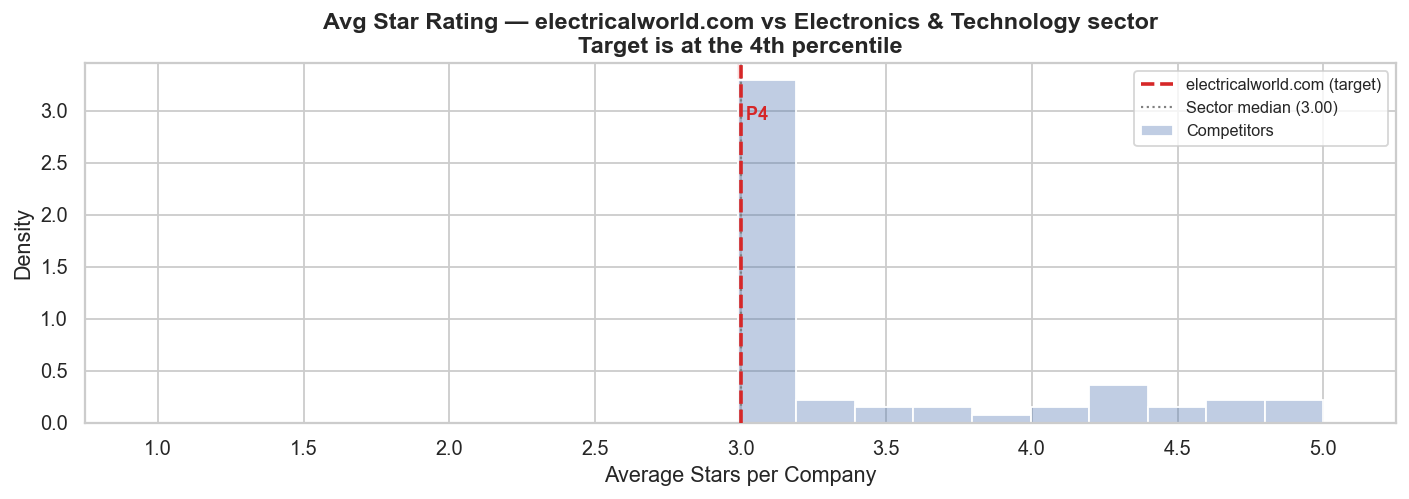

  ► electricalworld.com avg stars: 3.00  |  Sector median: 3.00  |  Percentile: 4th


In [53]:
eda.plot_stars_positioning(target_stats, CAT, TARGET)

``electricalworld.com`` sits at the **4th percentile** with an average of
3.00 stars — at the very bottom of the sector distribution. The KDE
shows most competitors cluster between 3.5 and 4.5 stars, meaning our
company is a clear negative outlier. The sector median is also 3.00,
but the distribution is right-skewed with a long tail of high performers,
pulling the average above electricalworld.com. In practical terms,
**96% of competitors in this sector have a higher average rating**.
This is a critical signal: the company is not just below average, it
is near the floor of the entire category.

### **2.2 Sentiment Split vs Benchmarks**

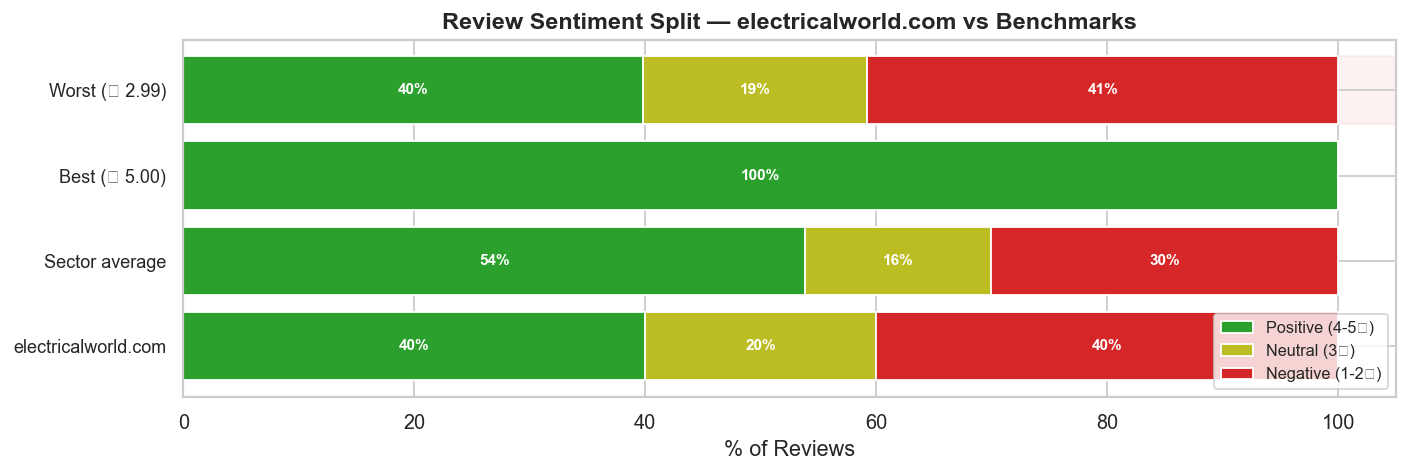

In [54]:
eda.plot_sentiment_pct_comparison(target_stats, TARGET)

The stacked bar chart tells a direct story. electricalworld.com has
**40% positive and 40% negative reviews** — a perfectly split, deeply
polarised customer base. This compares unfavourably to:
- The **sector average**: 54% positive, 30% negative
- The **best company**: 100% positive, 0% negative
- Even the **worst company** (★2.99): 40% positive, 41% negative —
  essentially identical to electricalworld.com

The fact that electricalworld.com matches the *worst-performing
company* in the sector on both positive and negative rates is the
clearest possible summary of its competitive position. The 20% neutral
block is average, offering no differentiation. **There is no meaningful
positive base to build on without first addressing the negative reviews.**

### **2.3 Percentile Dashboard (3 KPIs)**

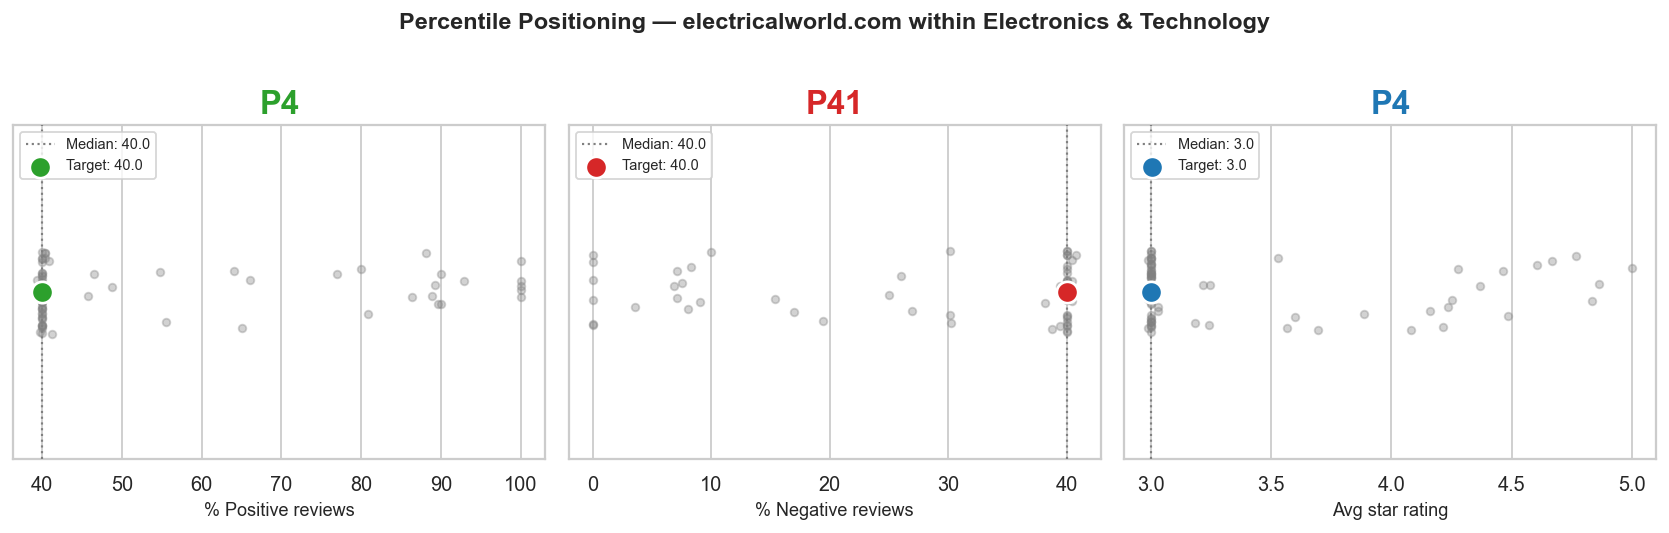

In [55]:
eda.plot_percentile_dashboard(target_stats, CAT, TARGET)

Three KPIs consolidate the positioning picture:

| KPI | Value | Percentile |
|-----|-------|------------|
| % Positive reviews | 40% | **P4** |
| % Negative reviews | 40% | **P41** |
| Avg star rating | 3.00 | **P4** |

The P41 on negative reviews is actually the *least* alarming figure —
being at the 41st percentile for negative rate means the company is
slightly below the median on that metric, which sounds counterintuitive
given the 40% negative rate. This reflects that many competitors also
have significant negative volumes. The real problem is the **P4 on
positive reviews**: only 4% of competitors have fewer positive reviews,
meaning electricalworld.com is almost uniquely bad at generating
satisfied customers.

### **2.4 Word Count by Sentiment vs Sector**

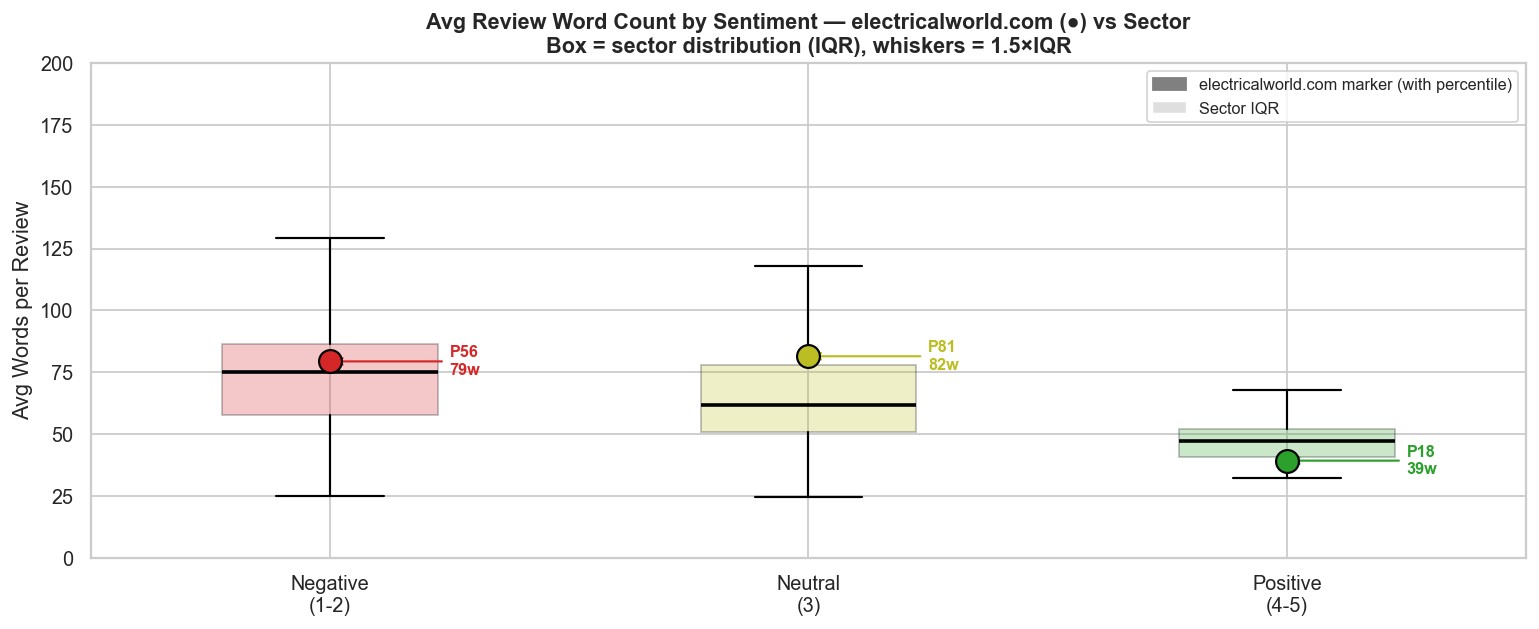

In [56]:
eda.plot_word_count_by_sentiment(target_stats, TARGET)

electricalworld.com's reviewers show a striking pattern:

| Sentiment | Our avg words | Sector IQR | Percentile |
|-----------|--------------|------------|------------|
| Negative | 79w | ~55–100w | **P56** |
| Neutral | 82w | ~40–80w | **P81** |
| Positive | 39w | ~25–60w | **P18** |

Negative and neutral reviewers write **more than sector average**
(P56 and P81 respectively), confirming that dissatisfied customers
are verbose and detailed in their complaints. Positive reviewers
write much less than competitors' happy customers (P18, only 39 words)
— suggesting that the small share of satisfied customers leave
**thin, unconvincing praise** that carries little weight. This imbalance
matters for reputation: long negative reviews are more persuasive to
prospective buyers than short positive ones.

## **3. NLP Topic Analysis**



In [57]:
df_target_full, df_comp_full, summary_target, summary_comp, topic_model = nlp.run_nlp_pipeline(df_clean, target=TARGET)

2026-04-16 11:01:23,982 [INFO] No device provided, using cpu


### **3.1 Topic Distribution — electricalworld.com**

In [ ]:
print(f"Topic distribution — {TARGET}")
nlp.plot_topic_distribution(df_target_full, title=TARGET)

The company's reviews concentrate almost entirely on **one dominant
topic**: T3 (customer service, quality, great service) with ~15 reviews
and net sentiment +73, which is the only topic with meaningful positive
signal. The remaining 8 topics each have fewer than 5 reviews, but
their sentiment is concerning:

- **T31** (order cancelled, refunded): net = −100
- **T25** (ordered item, delivery, customer service): net = −100
- **T14** (ordered wrong, refunded): net = −100
- **T11** (customer services, tried deliver): net = −33

Three topics score a perfect −100 net sentiment, meaning every single
review in those buckets is negative. The company has **no volume of
consistently positive secondary topics** — the positive signal is
almost entirely concentrated in the top topic. This fragility means
any deterioration in customer service quality would collapse the
entire positive narrative.

### **3.2 Topic Distribution — Competitors**

In [ ]:
print("\nTopic distribution — Competitors")
nlp.plot_topic_distribution(df_comp_full, title="Competitors")

The competitor landscape presents a starkly different picture.
Competitors have **15+ active topics** with healthy review volumes,
and the vast majority are green (dominant positive). The largest topic
T1 (received phone, refurbished, excellent condition) has ~370 reviews
at net +15, showing that refurbished electronics is a high-volume,
moderately positive segment. Topics T21 (service quick, friendly,
delivery excellent, net +86) and T26 (pleasant helpful, minor issue,
helpful phone, net +83) show competitors generating strong positive
sentiment around fast and friendly service. Crucially, **competitors
have no red bars** — their topic distribution contains no
predominantly negative topics, while electricalworld.com has four.

### **3.3 Sentiment Heatmap — electricalworld.com**

In [ ]:
print(f"Sentiment heatmap — {TARGET}")
nlp.plot_sentiment_heatmap(summary_target, title=TARGET)

The heatmap is stark in its contrasts. Two topics score 100% positive
(T2: customer service/purchase, T12: day delivery/quick delivery),
suggesting that when things go right — good service interaction or
fast delivery — customers are uniformly delighted. However, three
topics score **100% negative** (T14: wrong orders, T25: item
purchased/delivery, T31: order cancelled/refunded). These represent
operational failures: wrong items sent, failed deliveries, and
cancellation/refund processes. The 0% neutral rate in almost every
topic indicates that customers are not ambivalent — **every experience
drives a strong opinion in one direction or the other**.

### **3.4 Sentiment Heatmap — Competitors**

In [ ]:
print("Sentiment heatmap — Competitors")
nlp.plot_sentiment_heatmap(summary_comp, title="Competitors")

Competitors show a much more **graduated and balanced** heatmap.
Even the best-performing topics (T21 at 92% positive, T26 at 90%
positive) retain small negative tails, suggesting a realistic
distribution. The bottom of the heatmap does show negative-dominated
topics (T25 at 85% negative, T31 at 89% negative, T10 checkout/scam
at 78% negative), confirming that order cancellations and delivery
failures are **sector-wide pain points**, not unique to electricalworld.
The difference is that competitors have these negative topics as a
small fraction of their overall volume, whereas for electricalworld.com
they represent a disproportionate share of reviews.

### **3.5 Head-to-Head Net Sentiment Comparison**

In [ ]:
merged = nlp.plot_head_to_head(summary_target, summary_comp, target_name=TARGET)
nlp.print_strengths_weaknesses(merged, target_name=TARGET)

The grouped bar chart crystallises the competitive gaps:

**Strengths (electricalworld.com > competitors):**
- **T2** (customer service/purchase): gap = +117 — when a service
  interaction goes well, electricalworld.com customers are *more*
  positive than the sector average
- **T12** (day delivery/quick delivery): gap = +104 — fast delivery
  generates exceptional praise, far above competitors
- **T24** (delivering/day delivery): gap = +68
- **T37** (courier service/tried deliver): gap = +56

**Weaknesses (electricalworld.com < competitors):**
- **T14** (ordered wrong/refunded): gap = −93 — catastrophically
  worse than competitors when wrong items are sent
- **T25** (ordered item/delivery): gap = −16
- **T31** (order cancelled/refunded): gap = −11

The insight is clear: electricalworld.com excels at the **happy path**
(fast delivery, good service interactions) but catastrophically fails
at **exception handling** (wrong items, cancellations, refunds).
Competitors handle these failure modes significantly better.


### **3.6 Strengths, Weaknesses & Improvement Areas**

In [ ]:
# Explore a specific topic's raw reviews
topic_model.visualize_topics()          # interactive BERTopic plot
topic_model.visualize_barchart()        # top words per topic

**STRENGTHS**\
✅ Customer service interactions when positive → gap +117\
✅ Same-day / quick delivery → gap +104\
✅ General delivery experience → gap +68\
✅ Courier service satisfaction → gap +56\
✅ Overall customer quality perception → gap +29\

**WEAKNESSES**\
⚠️ Wrong item orders & refund process → gap −93\
⚠️ Item purchased + delivery failure → gap −16\
⚠️ Order cancellation & refund handling → gap −11\

**IMPROVEMENT AREAS (net sentiment in electricalworld.com)**\
🔧 Wrong orders / refunds → net −100 (priority 1)\
🔧 Item purchased / delivery failures → net −100 (priority 1)\
🔧 Order cancellations → net −100 (priority 1)\
🔧 Customer services / failed delivery → net −33 (priority 2)\

## **4. Summary & Strategic Recommendations**

### What the data says

electricalworld.com operates at the **bottom 4th percentile** of its
sector with a polarised 40/40 positive-negative split. The NLP analysis
reveals that this polarisation is not random — it maps to two distinct
operational modes:

1. **When the order goes right** → customers are *more* positive than
   competitors (delivery speed and service interactions generate
   top-quartile sentiment)
2. **When the order goes wrong** → customers are *far more* negative
   than competitors (wrong items, cancellations, and refund handling
   generate 100% negative reviews)

### Recommendations

| Priority | Area | Action |
|----------|------|--------|
| 🔴 Critical | Wrong item fulfilment | Audit warehouse picking accuracy; implement pre-dispatch item verification |
| 🔴 Critical | Cancellation & refund process | Simplify and accelerate refund workflows; communicate proactively |
| 🔴 Critical | Failed delivery handling | Improve courier partner SLA monitoring; offer immediate remediation |
| 🟡 Medium | Positive review volume | Happy customers write short reviews (39w avg); prompt them for more detail |
| 🟢 Maintain | Fast delivery & service | This is a genuine differentiator — protect and market it |

The strategic imperative is not to build on strengths — those already
outperform the sector. It is to **eliminate the failure modes that are
destroying the overall rating**, since even a moderate improvement in
order accuracy and refund handling would shift dozens of 1-star reviews
to 3-star or higher, moving the company out of the 4th percentile.